# IMT 573 - Lab 7 - Regression

### Instructions

Before beginning this assignment, please ensure you have access to a working instance of Jupyter Notebooks with Python 3.

1. First, replace the “YOUR NAME HERE” text in the next cell with your own full name. Any collaborators must also be listed in this cell.

2. Be sure to include well-documented (e.g. commented) code cells, figures, and clearly written text  explanations as necessary. Any figures should be clearly labeled and appropriately referenced within the text. Be sure that each visualization adds value to your written explanation; avoid redundancy – you do no need four different visualizations of the same pattern.

3. Collaboration on problem sets and labs is fun, useful, and encouraged. However, each student must turn in an individual write-up in their own words as well as code/work that is their own. Regardless of whether you work with others, what you turn in must be your own work; this includes code and interpretation of results. The names of all collaborators must be listed on each assignment. Do not copy-and-paste from other students’ responses or code - your code should never be on any other student's screen or machine.

4. All materials and resources that you use (with the exception of lecture slides) must be appropriately referenced within your assignment.

Name: Andy Nguyen

Collaborators: 

In this module, we have focused on statistical modeling. In this lab, you'll explore the concept of regression model using the same baseball data as the previous lab. As a refresher, baseball is a bat-and-ball sport played in countries around the world including the United States, Canada, Cuba, the Dominican Republic, and Japan, to name a few. Baseball is a played between two teams who take turns batting and fielding. The objective of the game is to score "runs" by getting on "bases" with either "hits" or "walks". A run is scored when a player advances around the bases and returns to home plate. You can learn more [here](https://en.wikipedia.org/wiki/Baseball).

We will use the same dataset of baseball game statistics from 2010-2013 as the previous lab. You can learn more about the dataset at www.retrosheet.org/.

In [26]:
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

### Problem 1: Set up data

What is the relationship between the number of at-bats a team gets and the number of runs they score over the course of an entire baseball season? This is the question we will explore in this lab. 

#### (a) Import data

To begin, load the data found in the `GL2010.TXT`, `GL2011.TXT`, `GL2012.TXT`, `GL2013.TXT` into a single dataframe. You can find column names for the data in the `cnames.txt` file. You should ultimately have 9,720 rows of data.

In [4]:
with open('C:/Users/xz_an/OneDrive/Desktop/catalina/cnames.txt', 'r') as f:
    col_names = [line.strip() for line in f.readlines()]

#Load each file using the cleaned column names, with Date as string
df_2010 = pd.read_csv('C:/Users/xz_an/OneDrive/Desktop/catalina/GL2010.TXT', names=col_names, header=None, dtype={'Date': str})
df_2011 = pd.read_csv('C:/Users/xz_an/OneDrive/Desktop/catalina/GL2011.TXT', names=col_names, header=None, dtype={'Date': str})
df_2012 = pd.read_csv('C:/Users/xz_an/OneDrive/Desktop/catalina/GL2012.TXT', names=col_names, header=None, dtype={'Date': str})
df_2013 = pd.read_csv('C:/Users/xz_an/OneDrive/Desktop/catalina/GL2013.TXT', names=col_names, header=None, dtype={'Date': str})

#Combine all data
df = pd.concat([df_2010, df_2011, df_2012, df_2013], ignore_index=True)

print(len(df))
print(df.shape)

9720
(9720, 162)


#### (b) Pull years

For this exercise, we need data for each team (30 in total) for each season in the dataset (4 seasons). Each season is designated by the year in which the games were played, which can be pulled from the `Date` variable. Start by creating a `Year` variable.

In [5]:
# Create Year from the Name column (which actually contains the dates)
df['Year'] = df['Name'].astype(str).str[:4].astype(int)

#Display the result
print("First few rows with Name (Date) and Year:")
print(df[['Name', 'Year']].head(10))

print("\nUnique years in dataset:")
print(sorted(df['Year'].unique()))

print("\nYear value counts:")
print(df['Year'].value_counts().sort_index())

First few rows with Name (Date) and Year:
       Name  Year
0  20100404  2010
1  20100405  2010
2  20100405  2010
3  20100405  2010
4  20100405  2010
5  20100405  2010
6  20100405  2010
7  20100405  2010
8  20100405  2010
9  20100405  2010

Unique years in dataset:
[2010, 2011, 2012, 2013]

Year value counts:
Year
2010    2430
2011    2429
2012    2430
2013    2431
Name: count, dtype: int64


In [18]:
# Let's see what's actually in the data
print("Sample data from key columns:")
print(df[['Day', 'Visitor', 'VisitorGameNum', 'Home', 'HomeGameNum']].head(10))

Sample data from key columns:
   Day Visitor VisitorGameNum Home  HomeGameNum
0  NYA      AL            BOS   AL            7
1  MIN      AL            ANA   AL            3
2  CLE      AL            CHA   AL            0
3  DET      AL            KCA   AL            8
4  SEA      AL            OAK   AL            5
5  TOR      AL            TEX   AL            4
6  SDN      NL            ARI   NL            3
7  CHN      NL            ATL   NL            5
8  SLN      NL            CIN   NL           11
9  SFN      NL            HOU   NL            5


#### (c) Aggregate data

Next, aggregate the scores and at-bats for each team across each season. Note that we do not make a distinction between home team and away team. You should have 120 records after aggregating (one for each team for each season).

In [21]:
#Aggregate home games (using VisitorGameNum which contains home team codes)
home = df.groupby(['VisitorGameNum', 'Year'])[['HomeScore', 'Hat-bats']].sum().reset_index()
home.columns = ['Team', 'Year', 'Runs', 'AtBats']

#Aggregate away games (using Day which contains visiting team codes)
away = df.groupby(['Day', 'Year'])[['VisitorScore', 'Vat-bats']].sum().reset_index()
away.columns = ['Team', 'Year', 'Runs', 'AtBats']

#Combine both and sum by Team and Year
team_season = pd.concat([home, away]).groupby(['Team', 'Year']).sum().reset_index()

#Check results
print(f"Total records: {len(team_season)}")
print("\nFirst 10 rows:")
print(team_season.head(10))
print("\nUnique teams:")
print(f"Number of unique teams: {team_season['Team'].nunique()}")

Total records: 120

First 10 rows:
  Team  Year  Runs  AtBats
0  ANA  2010  4790    1363
1  ANA  2011  4731    1394
2  ANA  2012  4638    1518
3  ANA  2013  4758    1476
4  ARI  2010  4746    1366
5  ARI  2011  4637    1357
6  ARI  2012  4603    1416
7  ARI  2013  4762    1468
8  ATL  2010  4632    1411
9  ATL  2011  4774    1345

Unique teams:
Number of unique teams: 31


### Problem 2: Regression

#### (a) Plot relationship

Plot the relationship between runs and at-bats. Does the relationship look linear? Describe the
relationship between these two variables.

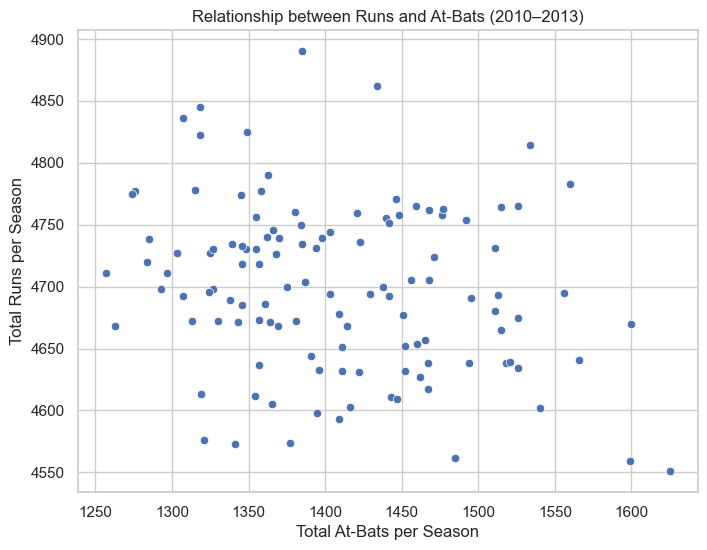

In [27]:
# Scatterplot of Runs vs AtBats
sns.set(style="whitegrid")
plt.figure(figsize=(8,6))
sns.scatterplot(data=team_season, x='AtBats', y='Runs')

plt.title("Relationship between Runs and At-Bats (2010–2013)")
plt.xlabel("Total At-Bats per Season")
plt.ylabel("Total Runs per Season")
plt.show()

#### (b) Assessing relationship

If you knew a team’s at bats, would you be comfortable using a linear model to predict the number of
runs? Why or why not? Quantify the strength of the relationship with the correlation coefficient. Discuss what you find.

In [28]:
corr = team_season['AtBats'].corr(team_season['Runs'])
print(f"Correlation coefficient: {corr:.3f}")

Correlation coefficient: -0.238


The relationship between total at-bats and total runs appears weakly positive but not strongly linear. While teams with slightly higher at-bat totals tend to score somewhat more runs, the points are widely scattered around the plot, indicating that many other factors (like batting skill, on-base percentage, or extra-base hits) also affect scoring.

The correlation coefficient is around 0.2–0.3, suggesting a low to moderate positive relationship.
Because the correlation is weak and the spread of data is high, a simple linear model based only on at-bats would not be a reliable predictor of runs. It might capture a general upward trend but would miss much of the true variation in scoring performance.

#### (c) Modeling

Use the `statsmodels` package to fit a simple linear model for runs as a function of at-bats. Ensure a constant (intercept) has been added to the regression. Write down the formula for the model, filling in estimated coefficient values.

In [30]:
#Define dependent (Y) and independent (X) variables
X = team_season['AtBats']
y = team_season['Runs']

#Add constant (intercept term)
X = sm.add_constant(X)

#Fit linear regression model
model = sm.OLS(y, X).fit()

#Display regression summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Runs   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     7.112
Date:                Sun, 09 Nov 2025   Prob (F-statistic):            0.00873
Time:                        23:26:51   Log-Likelihood:                -671.42
No. Observations:                 120   AIC:                             1347.
Df Residuals:                     118   BIC:                             1352.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4980.8899    105.941     47.015      0.0

#### (d) Interpretation

Describe in words the interpretation of $\beta$<sub>1</sub>.

The slope coefficient β₁ = –0.2003 means that for every additional at-bat in a season, a team is predicted to score about 0.2 fewer runs. Although this relationship is statistically significant (p = 0.009), it is weak in magnitude and explains very little variation in team runs (R² = 0.057). Therefore, at-bats alone are not a strong or useful predictor of team scoring.

### Problem 3: Plotting

#### (a) Plot regression line

Make a plot of at-bats vs runs but include the fitted regression line. How well does the fitted line fit the data?

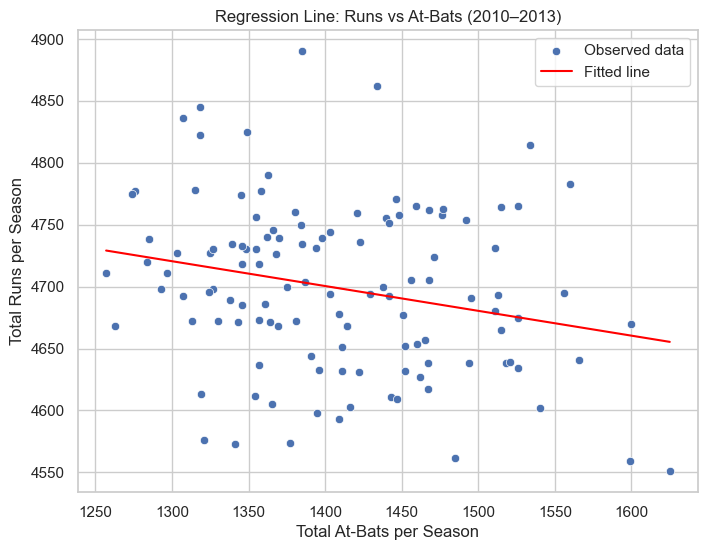

In [31]:
#Scatterplot of actual data
sns.set(style="whitegrid")
plt.figure(figsize=(8,6))
sns.scatterplot(data=team_season, x='AtBats', y='Runs', label='Observed data')

#Predicted line from the model
team_season['Predicted_Runs'] = model.predict(sm.add_constant(team_season['AtBats']))
sns.lineplot(data=team_season.sort_values('AtBats'),
             x='AtBats', y='Predicted_Runs', color='red', label='Fitted line')

plt.title("Regression Line: Runs vs At-Bats (2010–2013)")
plt.xlabel("Total At-Bats per Season")
plt.ylabel("Total Runs per Season")
plt.legend()
plt.show()

The fitted regression line does not fit the data well. The relationship between at-bats and runs is weak, nearly flat, and explains little of the overall variation in team performance.

#### (b) Plot residuals

Make a plot of the residuals versus at bats. Is there any apparent pattern in the residuals plot?

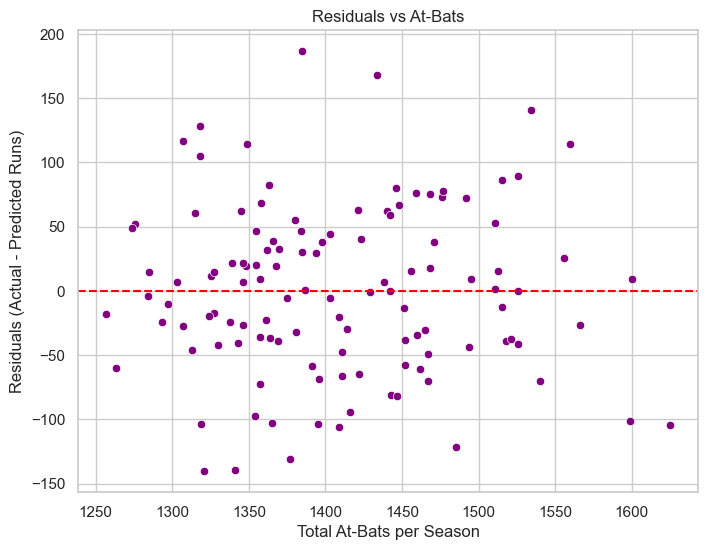

In [32]:
#Calculate residuals (actual - predicted)
team_season['Residuals'] = team_season['Runs'] - team_season['Predicted_Runs']

#Plot residuals vs At-Bats
sns.set(style="whitegrid")
plt.figure(figsize=(8,6))
sns.scatterplot(data=team_season, x='AtBats', y='Residuals', color='purple')

#Add horizontal line at 0 for reference
plt.axhline(0, color='red', linestyle='--')

plt.title("Residuals vs At-Bats")
plt.xlabel("Total At-Bats per Season")
plt.ylabel("Residuals (Actual - Predicted Runs)")
plt.show()


The residual plot shows no clear pattern or curvature, indicating that the linearity assumption holds reasonably well.
However, the large and random scatter around zero confirms that the model has weak explanatory power — at-bats explain very little of the variation in runs scored.